# Feature Engineering

1. Load one tar file and pull out a single face image
1. Run MediaPipe on it and look at the landmarks it gives us
1. Identify the specific landmarks we care about (iris centers, eye corners, eyelids)
1. Compute one feature — iris horizontal ratio — and make sure we understand the math
1. Add the other features one at a time
1. Check if the features actually separate the gaze classes
1. Once validated, run it across all the tars and save to parquet

# Setup

Imports and load data

In [ ]:
import numpy as np
import pandas as pd
import mediapipe as mp
from PIL import Image
import matplotlib.pyplot as plt

In [6]:
import glob
import webdataset as wds

TAR_DIR = "/Volumes/Crucial X10/210/gaze_wds_balanced"

# find whatever tars have downloaded so far
all_tars = sorted(glob.glob(f"{TAR_DIR}/**/*.tar", recursive=True))
print(f"Tar files found: {len(all_tars)}")

if all_tars:
    print(f"First tar: {all_tars[0]}")

Tar files found: 107
First tar: /Volumes/Crucial X10/210/gaze_wds_balanced/test/gaze-test-000000.tar


In [5]:
# load one sample from the first tar and see what's inside
ds = wds.WebDataset(all_tars[0]).decode("pil")
sample = next(iter(ds))

print("Sample key:", sample["__key__"])
print()
print("Files in this sample:")
for k in sorted(sample.keys()):
    if k.startswith("__"):
        continue
    val = sample[k]
    if hasattr(val, 'size'):  # PIL image
        print(f"  {k}: PIL image, size {val.size}")
    else:
        print(f"  {k}: {type(val).__name__}, {repr(val)[:100]}")

Sample key: 00003_000000

Files in this sample:
  face.jpg: PIL image, size (112, 112)
  json: dict, {'subject_id': '00003', 'frame_idx': 0, 'pog_x': 1.93875, 'pog_y': -9.46745070423}
  left.jpg: PIL image, size (60, 36)
  right.jpg: PIL image, size (60, 36)


/opt/anaconda3/envs/itracker/lib/python3.11/site-packages/webdataset/compat.py:379: UserWarning: WebDataset(shardshuffle=...) is None; set explicitly to False or a number
  warnings.warn("WebDataset(shardshuffle=...) is None; set explicitly to False or a number")


# Check single file

In [6]:
# Pull out the face image from our sample
face_img = sample["face.jpg"]
face_np = np.array(face_img)

print(f"Face image shape: {face_np.shape}")

# Run MediaPipe FaceMesh
mp_face_mesh = mp.solutions.face_mesh

with mp_face_mesh.FaceMesh(
    static_image_mode=True,
    max_num_faces=1,
    refine_landmarks=True,   # CRITICAL — this gives us iris landmarks (468-477)
    min_detection_confidence=0.5,
) as face_mesh:
    results = face_mesh.process(face_np)

if results.multi_face_landmarks:
    lms = results.multi_face_landmarks[0].landmark
    print(f"Landmarks detected: {len(lms)}")
else:
    print("No face detected — this is a problem")

Face image shape: (112, 112, 3)
Landmarks detected: 478


I0000 00:00:1772686716.966802       1 gl_context.cc:344] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


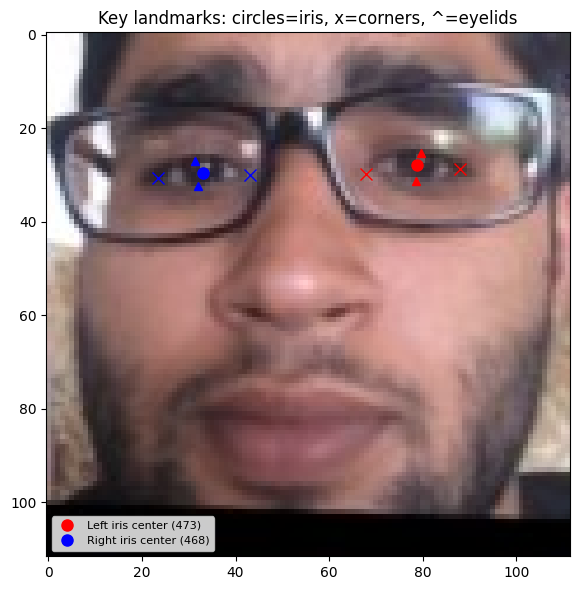

In [7]:
# Visualize the key landmarks on the face image

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.imshow(face_np)

h, w = face_np.shape[:2]

# Helper: landmark index → pixel coords
def lm_px(idx):
    return lms[idx].x * w, lms[idx].y * h

# Iris centers (the big ones)
left_iris = lm_px(473)    # subject's left eye
right_iris = lm_px(468)   # subject's right eye
ax.plot(*left_iris, 'ro', markersize=8, label='Left iris center (473)')
ax.plot(*right_iris, 'bo', markersize=8, label='Right iris center (468)')

# Eye corners
for idx, color, name in [
    (263, 'r', 'L eye lateral (263)'),
    (362, 'r', 'L eye medial (362)'),
    (33,  'b', 'R eye lateral (33)'),
    (133, 'b', 'R eye medial (133)'),
]:
    x, y = lm_px(idx)
    ax.plot(x, y, 'x', color=color, markersize=8)

# Eyelid landmarks
for idx, color in [(386, 'r'), (374, 'r'), (159, 'b'), (145, 'b')]:
    x, y = lm_px(idx)
    ax.plot(x, y, '^', color=color, markersize=6)

ax.legend(fontsize=8, loc='lower left')
ax.set_title("Key landmarks: circles=iris, x=corners, ^=eyelids")
plt.tight_layout()
plt.show()

In [8]:
# Compute iris horizontal ratio for the LEFT eye
# This is THE key feature: where is the iris sitting between the eye corners?

def lm_px(idx):
    """Landmark index → (x, y) in pixel coords."""
    return lms[idx].x * w, lms[idx].y * h

h, w = face_np.shape[:2]

# Subject's left eye
left_iris    = np.array(lm_px(473))
left_lateral = np.array(lm_px(263))   # outer corner
left_medial  = np.array(lm_px(362))   # inner corner

# Project iris onto the axis between the two corners
axis = left_medial - left_lateral
axis_len = np.linalg.norm(axis)
ratio = np.dot(left_iris - left_lateral, axis) / (axis_len ** 2)

print(f"Left eye iris horizontal ratio: {ratio:.3f}")
print()
print("What this means:")
print("  0.0 = iris at outer corner (looking away from nose)")
print("  0.5 = iris centered (looking straight)")
print("  1.0 = iris at inner corner (looking toward nose)")

Left eye iris horizontal ratio: 0.453

What this means:
  0.0 = iris at outer corner (looking away from nose)
  0.5 = iris centered (looking straight)
  1.0 = iris at inner corner (looking toward nose)


In [9]:
# Compute all 4 iris ratios for this sample

def ratio_along_axis(point, corner_a, corner_b):
    """Ratio of point's position along axis from corner_a to corner_b."""
    axis = corner_b - corner_a
    axis_len = np.linalg.norm(axis)
    if axis_len < 1e-6:
        return 0.5
    t = np.dot(point - corner_a, axis) / (axis_len ** 2)
    return float(np.clip(t, 0.0, 1.0))

# Subject's left eye
left_iris    = np.array(lm_px(473))
left_lateral = np.array(lm_px(263))
left_medial  = np.array(lm_px(362))
left_top     = np.array(lm_px(386))
left_bottom  = np.array(lm_px(374))

# Subject's right eye
right_iris    = np.array(lm_px(468))
right_lateral = np.array(lm_px(33))
right_medial  = np.array(lm_px(133))
right_top     = np.array(lm_px(159))
right_bottom  = np.array(lm_px(145))

# Horizontal ratios (lateral → medial, so 0.5 = centered)
left_h  = ratio_along_axis(left_iris,  left_lateral,  left_medial)
right_h = ratio_along_axis(right_iris, right_lateral, right_medial)

# Vertical ratios (top → bottom, so 0.5 = centered)
left_v  = ratio_along_axis(left_iris,  left_top,  left_bottom)
right_v = ratio_along_axis(right_iris, right_top, right_bottom)

print(f"Left eye  — horizontal: {left_h:.3f}   vertical: {left_v:.3f}")
print(f"Right eye — horizontal: {right_h:.3f}   vertical: {right_v:.3f}")
print(f"Agreement — horizontal: {left_h - right_h:.3f}   vertical: {left_v - right_v:.3f}")
print()
print(f"Ground truth PoG: x={sample['json']['pog_x']:.2f}, y={sample['json']['pog_y']:.2f}")
print()
print("Sanity check:")
print(f"  Both h ratios < 0.5 → looking right ✓" if left_h < 0.5 and right_h < 0.5 else "")
print(f"  Both v ratios > 0.5 → looking down ✓" if left_v > 0.5 and right_v > 0.5 else "")

Left eye  — horizontal: 0.453   vertical: 0.444
Right eye — horizontal: 0.489   vertical: 0.476
Agreement — horizontal: -0.036   vertical: -0.032

Ground truth PoG: x=1.94, y=-9.47

Sanity check:
  Both h ratios < 0.5 → looking right ✓



# Check Batch

check for class separation in new features

In [11]:
df_labels = pd.read_csv('/Volumes/Crucial X10/210/gaze_labels.csv', dtype={'subject_id': str})
print(f"Loaded {len(df_labels)} labeled frames")
print()
print(df_labels.head())
print()
print(df_labels['label'].value_counts())

Loaded 849131 labeled frames

  subject_id  frame_idx     pog_x     pog_y     label
0      00002          0  1.064000 -6.005500      Down
1      00002          1  1.064000 -6.005500      Down
2      00002          2  1.064000 -6.005500      Down
3      00002          3  1.064000 -6.005500      Down
4      00002          4  3.251485 -1.993073  Straight

label
Straight    246664
Down        213320
Left        188773
Right       180056
Up           20318
Name: count, dtype: int64


In [12]:
# Build label lookup keyed by tar sample key
label_lookup = {}
for _, row in df_labels.iterrows():
    key = f"{row['subject_id']}_{int(row['frame_idx']):06d}"
    label_lookup[key] = row['label']

print(f"Label lookup built: {len(label_lookup)} entries")
print()

# Check if our sample matches
sample_key = sample["__key__"]
print(f"Sample key: {sample_key}")
print(f"Label:      {label_lookup.get(sample_key, 'NOT FOUND')}")

Label lookup built: 849131 entries

Sample key: 00003_000000
Label:      Down


In [13]:
# Compute features across 2000 samples from the train tars
from tqdm import tqdm

train_tars = sorted(glob.glob(f"{TAR_DIR}/train/*.tar"))
print(f"Train tars: {len(train_tars)}")

mp_face_mesh = mp.solutions.face_mesh

records = []
fail_count = 0
target_n = 2000

with mp_face_mesh.FaceMesh(
    static_image_mode=True,
    max_num_faces=1,
    refine_landmarks=True,
    min_detection_confidence=0.5,
) as face_mesh:

    ds = wds.WebDataset(train_tars, shardshuffle=False).decode("pil")

    for sample in tqdm(ds, total=target_n, desc="Computing features"):
        key = sample["__key__"]
        label = label_lookup.get(key)
        if label is None:
            continue

        face_img = np.array(sample["face.jpg"])
        h, w = face_img.shape[:2]
        results = face_mesh.process(face_img)

        if not results.multi_face_landmarks or len(results.multi_face_landmarks[0].landmark) < 478:
            fail_count += 1
            continue

        lms = results.multi_face_landmarks[0].landmark

        def lm_px(idx):
            return np.array([lms[idx].x * w, lms[idx].y * h])

        # Iris ratios
        left_h  = ratio_along_axis(lm_px(473), lm_px(263), lm_px(362))
        right_h = ratio_along_axis(lm_px(468), lm_px(33),  lm_px(133))
        left_v  = ratio_along_axis(lm_px(473), lm_px(386), lm_px(374))
        right_v = ratio_along_axis(lm_px(468), lm_px(159), lm_px(145))

        records.append({
            'key': key,
            'label': label,
            'left_h': left_h,
            'right_h': right_h,
            'left_v': left_v,
            'right_v': right_v,
        })

        if len(records) >= target_n:
            break

df_feat = pd.DataFrame(records)
print(f"\nComputed features for {len(df_feat)} samples, {fail_count} failures")
print(df_feat['label'].value_counts())

I0000 00:00:1772689004.134525       1 gl_context.cc:344] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1


Train tars: 75


Computing features: 4572it [00:16, 269.71it/s]                           


Computed features for 2000 samples, 2 failures
label
Down        635
Left        575
Straight    556
Right       227
Up            7
Name: count, dtype: int64


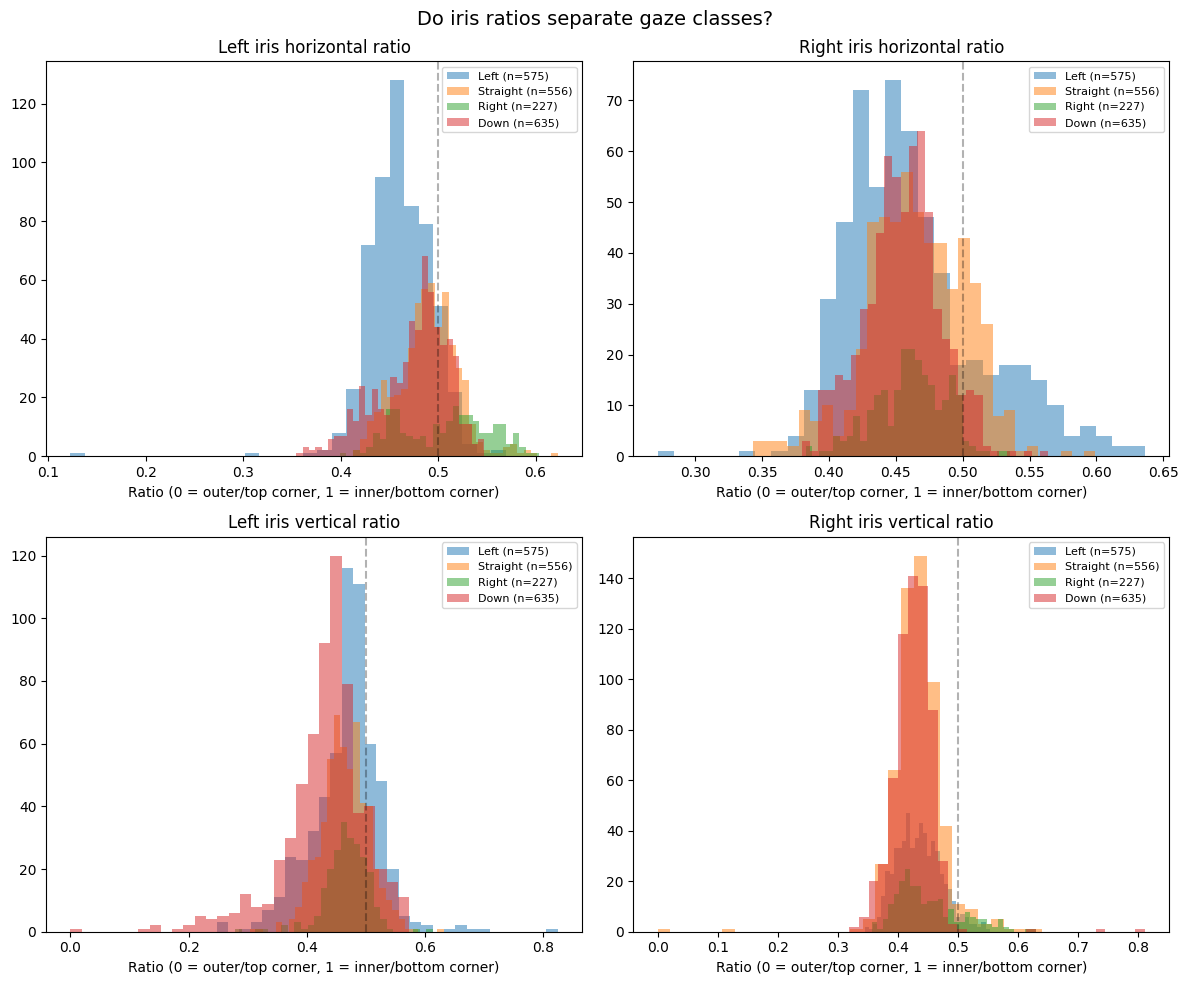

In [15]:
# ============================================================
# VALIDATION: Do iris ratios separate gaze classes?
# This is the critical check — if these distributions don't
# separate, the features won't help the model.
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Each tuple: (column name in df_feat, human-readable title)
features_to_plot = [
    ('left_h', 'Left iris horizontal ratio'),
    ('right_h', 'Right iris horizontal ratio'),
    ('left_v', 'Left iris vertical ratio'),
    ('right_v', 'Right iris vertical ratio'),
]

# Skip "Up" because we only have 7 samples — not enough to see a pattern
classes_to_plot = ['Left', 'Straight', 'Right', 'Down']

for ax, (col, title) in zip(axes.flat, features_to_plot):
    # Overlay a histogram for each class so we can see if they separate
    for label in classes_to_plot:
        vals = df_feat[df_feat['label'] == label][col]
        ax.hist(vals, bins=30, alpha=0.5, label=f"{label} (n={len(vals)})")

    ax.set_title(title)
    ax.set_xlabel('Ratio (0 = outer/top corner, 1 = inner/bottom corner)')
    ax.legend(fontsize=8)

    # Dashed line at 0.5 = "perfectly centered iris"
    ax.axvline(x=0.5, color='black', linestyle='--', alpha=0.3)

plt.suptitle("Do iris ratios separate gaze classes?", fontsize=14)
plt.tight_layout()
plt.show()

I0000 00:00:1772689476.530988       1 gl_context.cc:344] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1
Computing eye aspect ratios: 4572it [00:16, 281.88it/s]                           


Computed eye aspect ratios for 2000 samples


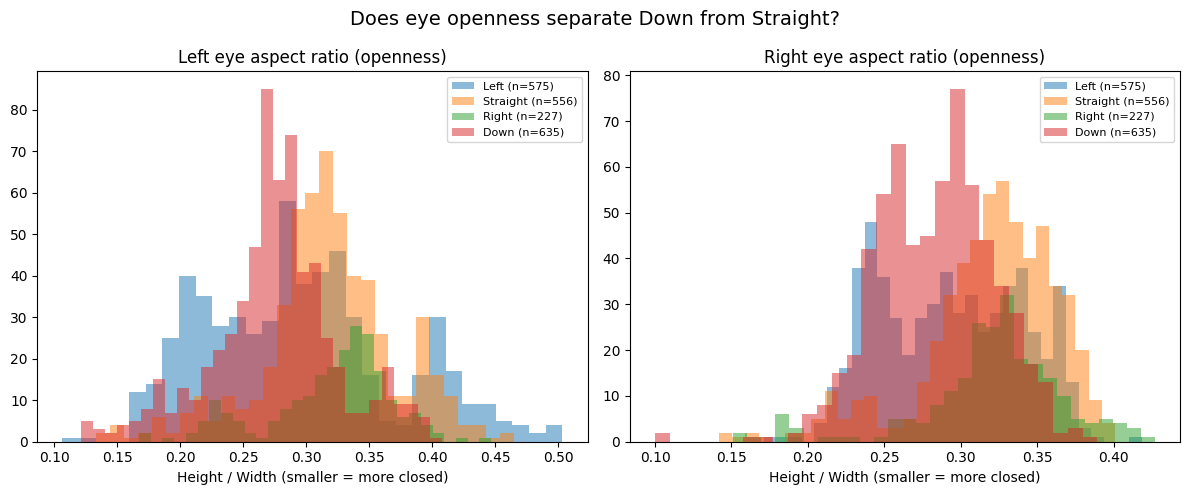

In [16]:
# ============================================================
# CHECK: Does eye aspect ratio (openness) separate Down from Straight?
# Eye aspect ratio = eye height / eye width
# When looking down, eyelids partially close → smaller ratio
# ============================================================

# Compute eye aspect ratio from the data we already have
# We need to go back and compute it in the loop, but we can
# derive it from the landmark positions we used for vertical ratio.
# Instead, let's add it to df_feat by recomputing on a fresh pass.
# Actually — let's just compute it from the raw landmarks we stored... 
# We didn't store them. So let's do a quick targeted pass.

ear_records = []

with mp_face_mesh.FaceMesh(
    static_image_mode=True,
    max_num_faces=1,
    refine_landmarks=True,
    min_detection_confidence=0.5,
) as face_mesh:

    ds = wds.WebDataset(train_tars, shardshuffle=False).decode("pil")

    for sample in tqdm(ds, total=2500, desc="Computing eye aspect ratios"):
        key = sample["__key__"]
        label = label_lookup.get(key)
        if label is None:
            continue

        face_img = np.array(sample["face.jpg"])
        h, w = face_img.shape[:2]
        results = face_mesh.process(face_img)

        if not results.multi_face_landmarks or len(results.multi_face_landmarks[0].landmark) < 478:
            continue

        lms = results.multi_face_landmarks[0].landmark

        def lm_px(idx):
            return np.array([lms[idx].x * w, lms[idx].y * h])

        # Eye corners (width)
        left_width  = np.linalg.norm(lm_px(362) - lm_px(263))
        right_width = np.linalg.norm(lm_px(133) - lm_px(33))

        # Eyelid top to bottom (height)
        left_height  = np.linalg.norm(lm_px(386) - lm_px(374))
        right_height = np.linalg.norm(lm_px(159) - lm_px(145))

        # Aspect ratio = height / width (smaller = more closed)
        left_ear  = left_height  / max(left_width,  1e-6)
        right_ear = right_height / max(right_width, 1e-6)

        ear_records.append({
            'key': key,
            'label': label,
            'left_ear': left_ear,
            'right_ear': right_ear,
        })

        if len(ear_records) >= 2000:
            break

df_ear = pd.DataFrame(ear_records)
print(f"Computed eye aspect ratios for {len(df_ear)} samples")

# ---- Plot ----
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (col, title) in zip(axes, [
    ('left_ear', 'Left eye aspect ratio (openness)'),
    ('right_ear', 'Right eye aspect ratio (openness)'),
]):
    for label in ['Left', 'Straight', 'Right', 'Down']:
        vals = df_ear[df_ear['label'] == label][col]
        ax.hist(vals, bins=30, alpha=0.5, label=f"{label} (n={len(vals)})")
    ax.set_title(title)
    ax.set_xlabel('Height / Width (smaller = more closed)')
    ax.legend(fontsize=8)

plt.suptitle("Does eye openness separate Down from Straight?", fontsize=14)
plt.tight_layout()
plt.show()

I0000 00:00:1772689704.897987       1 gl_context.cc:344] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1
Computing head pose: 4572it [00:17, 264.13it/s]                          


Computed head pose for 2000 samples


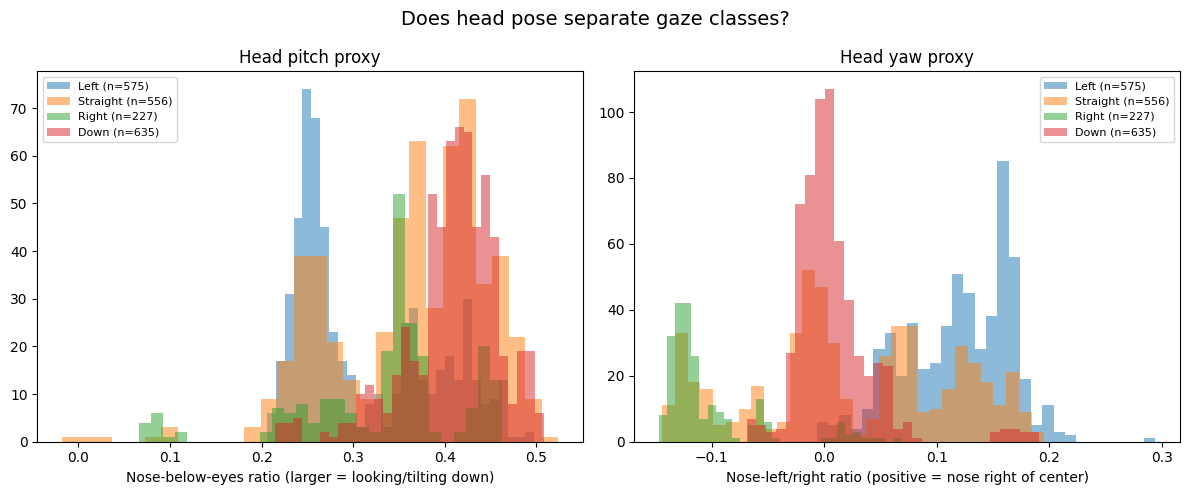

In [17]:
# ============================================================
# CHECK: Does head pitch separate Down from Straight?
# Head pitch proxy = vertical offset of nose tip relative to
# the midpoint between the outer eye corners, normalized by
# the distance between those corners (scale-invariant).
# Idea: when head tilts down, nose tip moves lower relative
# to the eyes → larger pitch value.
# ============================================================

pose_records = []

with mp_face_mesh.FaceMesh(
    static_image_mode=True,
    max_num_faces=1,
    refine_landmarks=True,
    min_detection_confidence=0.5,
) as face_mesh:

    ds = wds.WebDataset(train_tars, shardshuffle=False).decode("pil")

    for sample in tqdm(ds, total=2500, desc="Computing head pose"):
        key = sample["__key__"]
        label = label_lookup.get(key)
        if label is None:
            continue

        face_img = np.array(sample["face.jpg"])
        h, w = face_img.shape[:2]
        results = face_mesh.process(face_img)

        if not results.multi_face_landmarks or len(results.multi_face_landmarks[0].landmark) < 478:
            continue

        lms = results.multi_face_landmarks[0].landmark

        def lm_px(idx):
            return np.array([lms[idx].x * w, lms[idx].y * h])

        # Nose tip
        nose = lm_px(1)

        # Outer eye corners — midpoint is our "eye line" reference
        left_outer  = lm_px(263)
        right_outer = lm_px(33)
        eye_center_x = (left_outer[0] + right_outer[0]) / 2.0
        eye_center_y = (left_outer[1] + right_outer[1]) / 2.0

        # Distance between outer corners (for normalization)
        eye_span = abs(left_outer[0] - right_outer[0])

        # Pitch proxy: how far below the eye line is the nose?
        # Positive = nose below eyes (head tilted down or face looking down)
        head_pitch = (nose[1] - eye_center_y) / max(eye_span, 1e-6)

        # Yaw proxy: how far left/right of center is the nose?
        # Positive = nose right of center
        head_yaw = (nose[0] - eye_center_x) / max(eye_span, 1e-6)

        pose_records.append({
            'key': key,
            'label': label,
            'head_pitch': head_pitch,
            'head_yaw': head_yaw,
        })

        if len(pose_records) >= 2000:
            break

df_pose = pd.DataFrame(pose_records)
print(f"Computed head pose for {len(df_pose)} samples")

# ---- Plot ----
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pitch — does it separate Down from Straight?
ax = axes[0]
for label in ['Left', 'Straight', 'Right', 'Down']:
    vals = df_pose[df_pose['label'] == label]['head_pitch']
    ax.hist(vals, bins=30, alpha=0.5, label=f"{label} (n={len(vals)})")
ax.set_title('Head pitch proxy')
ax.set_xlabel('Nose-below-eyes ratio (larger = looking/tilting down)')
ax.legend(fontsize=8)

# Yaw — does it help with Left/Right?
ax = axes[1]
for label in ['Left', 'Straight', 'Right', 'Down']:
    vals = df_pose[df_pose['label'] == label]['head_yaw']
    ax.hist(vals, bins=30, alpha=0.5, label=f"{label} (n={len(vals)})")
ax.set_title('Head yaw proxy')
ax.set_xlabel('Nose-left/right ratio (positive = nose right of center)')
ax.legend(fontsize=8)

plt.suptitle("Does head pose separate gaze classes?", fontsize=14)
plt.tight_layout()
plt.show()

Finding pupil positions: 4570it [00:02, 1812.32it/s]                          


Computed pupil positions for 4000 eye crops


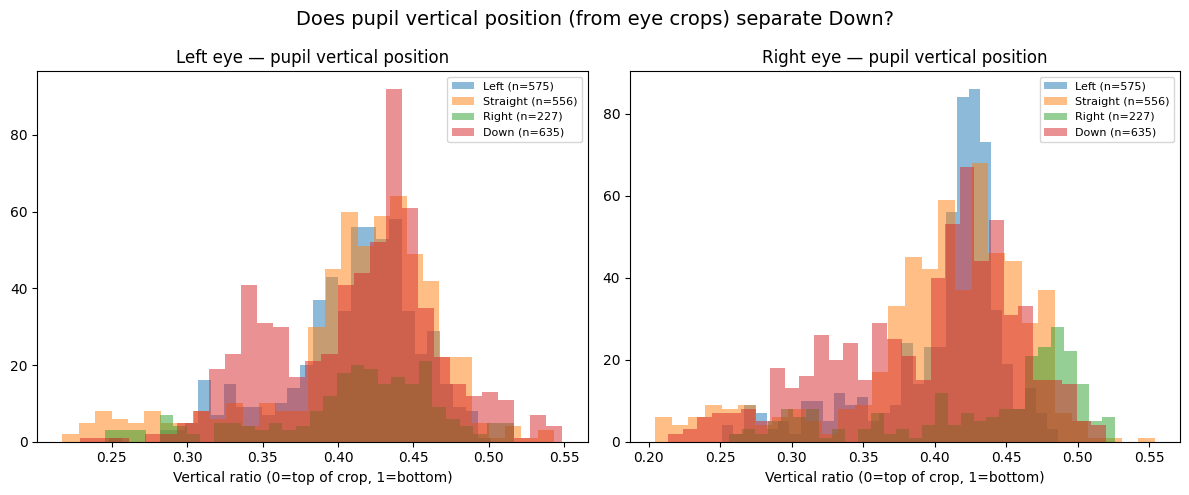

In [18]:
# ============================================================
# CHECK: Can we find vertical pupil position from the eye crops?
# 
# Idea: the darkest region in the eye crop is the pupil/iris.
# If we find its vertical centroid as a ratio of crop height,
# it might separate Down (pupil higher in crop because 
# eyelid droops, or pupil rotated down) from Straight.
#
# This uses the raw eye crops (60x36), NOT MediaPipe.
# ============================================================

import cv2

pupil_records = []

ds = wds.WebDataset(train_tars, shardshuffle=False).decode("pil")

for sample in tqdm(ds, total=2500, desc="Finding pupil positions"):
    key = sample["__key__"]
    label = label_lookup.get(key)
    if label is None:
        continue

    for eye_name in ['left', 'right']:
        eye_img = np.array(sample[f"{eye_name}.jpg"])

        # Convert to grayscale
        gray = cv2.cvtColor(eye_img, cv2.COLOR_RGB2GRAY)

        # Blur to smooth out noise
        blurred = cv2.GaussianBlur(gray, (7, 7), 0)

        # Find the darkest region — threshold at the lowest 15% of intensity
        thresh_val = np.percentile(blurred, 15)
        dark_mask = (blurred <= thresh_val).astype(np.uint8)

        # Find centroid of the dark region
        ys, xs = np.where(dark_mask)
        if len(ys) == 0:
            continue

        # Centroid as ratio of image dimensions
        # v_ratio: 0 = top of crop, 1 = bottom of crop
        cx = np.mean(xs) / gray.shape[1]
        cy = np.mean(ys) / gray.shape[0]

        pupil_records.append({
            'key': key,
            'label': label,
            'eye': eye_name,
            'pupil_h': cx,   # horizontal position in crop
            'pupil_v': cy,   # vertical position in crop
        })

    if len(pupil_records) >= 4000:  # ~2000 samples × 2 eyes
        break

df_pupil = pd.DataFrame(pupil_records)
print(f"Computed pupil positions for {len(df_pupil)} eye crops")

# ---- Plot vertical position by class ----
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, eye_name in zip(axes, ['left', 'right']):
    subset = df_pupil[df_pupil['eye'] == eye_name]
    for label in ['Left', 'Straight', 'Right', 'Down']:
        vals = subset[subset['label'] == label]['pupil_v']
        ax.hist(vals, bins=30, alpha=0.5, label=f"{label} (n={len(vals)})")
    ax.set_title(f'{eye_name.capitalize()} eye — pupil vertical position')
    ax.set_xlabel('Vertical ratio (0=top of crop, 1=bottom)')
    ax.legend(fontsize=8)

plt.suptitle("Does pupil vertical position (from eye crops) separate Down?", fontsize=14)
plt.tight_layout()
plt.show()

I0000 00:00:1772690301.095193       1 gl_context.cc:344] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1
Computing z-depth features: 4572it [00:16, 284.48it/s]                           


Computed z-depth features for 2000 samples


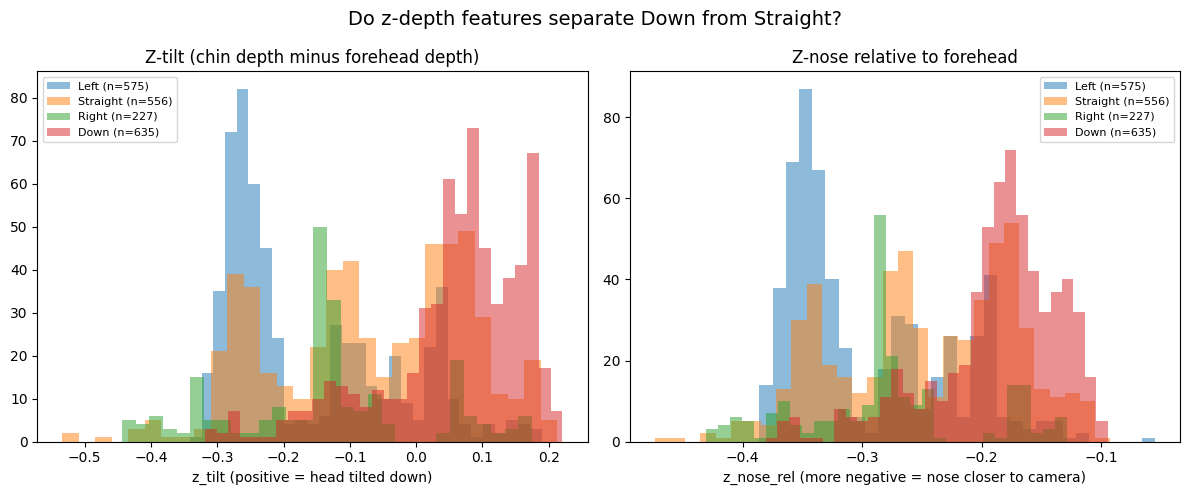

In [19]:
# ============================================================
# CHECK: Do MediaPipe z-coordinates capture head tilt (pitch)?
#
# Every MediaPipe landmark has a .z value — relative depth
# from the camera. When head tilts down:
#   - forehead comes closer to camera (smaller z)
#   - chin recedes away from camera (larger z)
#
# Key landmarks:
#   10  = top of forehead (center)
#   152 = chin tip
#   1   = nose tip
#
# We'll compute:
#   z_tilt = z(chin) - z(forehead)
#     positive = chin further away = head tilted down
#   z_nose = z(nose) - z(forehead)  
#     as a secondary signal
# ============================================================

z_records = []

with mp_face_mesh.FaceMesh(
    static_image_mode=True,
    max_num_faces=1,
    refine_landmarks=True,
    min_detection_confidence=0.5,
) as face_mesh:

    ds = wds.WebDataset(train_tars, shardshuffle=False).decode("pil")

    for sample in tqdm(ds, total=2500, desc="Computing z-depth features"):
        key = sample["__key__"]
        label = label_lookup.get(key)
        if label is None:
            continue

        face_img = np.array(sample["face.jpg"])
        h, w = face_img.shape[:2]
        results = face_mesh.process(face_img)

        if not results.multi_face_landmarks or len(results.multi_face_landmarks[0].landmark) < 478:
            continue

        lms = results.multi_face_landmarks[0].landmark

        # z values are normalized by face width (per MediaPipe docs)
        # More negative = closer to camera
        z_forehead = lms[10].z
        z_chin     = lms[152].z
        z_nose     = lms[1].z

        # Tilt signal: positive = chin further from camera = head tilted down
        z_tilt = z_chin - z_forehead

        # Nose depth relative to forehead (secondary signal)
        z_nose_rel = z_nose - z_forehead

        z_records.append({
            'key': key,
            'label': label,
            'z_tilt': z_tilt,
            'z_nose_rel': z_nose_rel,
        })

        if len(z_records) >= 2000:
            break

df_z = pd.DataFrame(z_records)
print(f"Computed z-depth features for {len(df_z)} samples")

# ---- Plot ----
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# z_tilt: does it separate Down from Straight?
ax = axes[0]
for label in ['Left', 'Straight', 'Right', 'Down']:
    vals = df_z[df_z['label'] == label]['z_tilt']
    ax.hist(vals, bins=30, alpha=0.5, label=f"{label} (n={len(vals)})")
ax.set_title('Z-tilt (chin depth minus forehead depth)')
ax.set_xlabel('z_tilt (positive = head tilted down)')
ax.legend(fontsize=8)

# z_nose_rel: secondary signal
ax = axes[1]
for label in ['Left', 'Straight', 'Right', 'Down']:
    vals = df_z[df_z['label'] == label]['z_nose_rel']
    ax.hist(vals, bins=30, alpha=0.5, label=f"{label} (n={len(vals)})")
ax.set_title('Z-nose relative to forehead')
ax.set_xlabel('z_nose_rel (more negative = nose closer to camera)')
ax.legend(fontsize=8)

plt.suptitle("Do z-depth features separate Down from Straight?", fontsize=14)
plt.tight_layout()
plt.show()

I0000 00:00:1772690742.047975       1 gl_context.cc:344] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1
Computing upper face ratios: 4572it [00:16, 273.55it/s]                           


Computed upper face ratios for 2000 samples


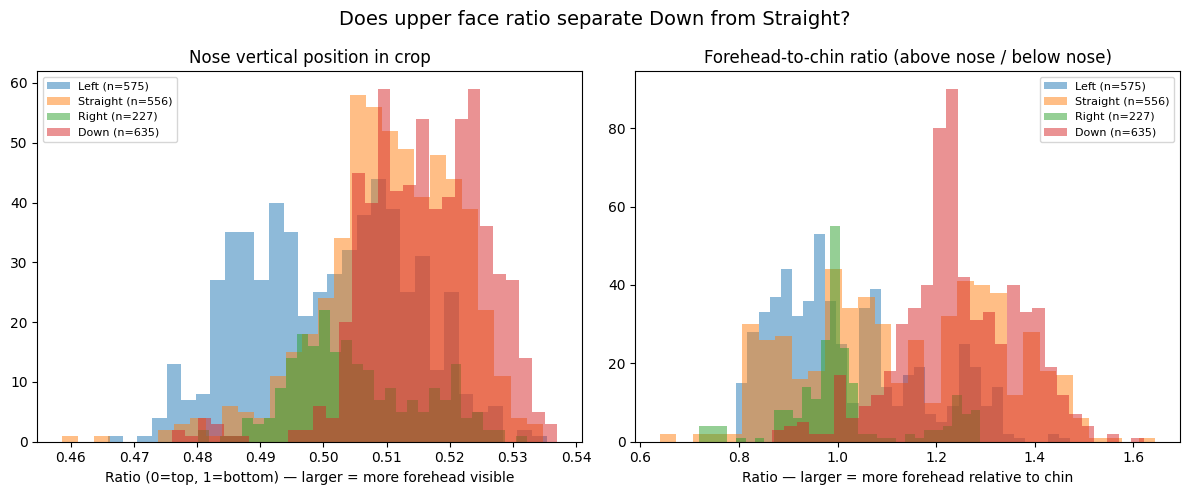

In [20]:
# ============================================================
# CHECK: Does upper face ratio separate Down from Straight?
#
# When someone looks down at a phone, their head tilts forward,
# exposing more forehead in the camera's view. The face crop
# then has more space above the nose than below it.
#
# Upper face ratio = (nose_y - top_of_crop) / (bottom_of_crop - top_of_crop)
#   = nose_y / crop_height
#
# Simpler version: nose_y / chin_y
#   (how far down the face is the nose? if forehead is large,
#    nose sits lower in the crop → larger ratio)
#
# Key landmarks:
#   1   = nose tip
#   10  = top of forehead
#   152 = chin
# ============================================================

face_ratio_records = []

with mp_face_mesh.FaceMesh(
    static_image_mode=True,
    max_num_faces=1,
    refine_landmarks=True,
    min_detection_confidence=0.5,
) as face_mesh:

    ds = wds.WebDataset(train_tars, shardshuffle=False).decode("pil")

    for sample in tqdm(ds, total=2500, desc="Computing upper face ratios"):
        key = sample["__key__"]
        label = label_lookup.get(key)
        if label is None:
            continue

        face_img = np.array(sample["face.jpg"])
        h, w = face_img.shape[:2]
        results = face_mesh.process(face_img)

        if not results.multi_face_landmarks or len(results.multi_face_landmarks[0].landmark) < 478:
            continue

        lms = results.multi_face_landmarks[0].landmark

        # Y positions in pixels (0 = top of image, h = bottom)
        nose_y     = lms[1].y * h
        forehead_y = lms[10].y * h
        chin_y     = lms[152].y * h

        # Ratio 1: nose position relative to crop boundaries
        # Larger = nose sits lower in image = more forehead visible
        nose_in_crop = nose_y / h

        # Ratio 2: forehead-to-nose vs nose-to-chin
        # Larger = more forehead relative to chin area = head tilted down
        forehead_span = nose_y - forehead_y    # pixels of forehead above nose
        chin_span     = chin_y - nose_y        # pixels of chin below nose
        upper_lower_ratio = forehead_span / max(chin_span, 1e-6)

        face_ratio_records.append({
            'key': key,
            'label': label,
            'nose_in_crop': nose_in_crop,
            'upper_lower_ratio': upper_lower_ratio,
        })

        if len(face_ratio_records) >= 2000:
            break

df_face_ratio = pd.DataFrame(face_ratio_records)
print(f"Computed upper face ratios for {len(df_face_ratio)} samples")

# ---- Plot ----
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Nose position in crop
ax = axes[0]
for label in ['Left', 'Straight', 'Right', 'Down']:
    vals = df_face_ratio[df_face_ratio['label'] == label]['nose_in_crop']
    ax.hist(vals, bins=30, alpha=0.5, label=f"{label} (n={len(vals)})")
ax.set_title('Nose vertical position in crop')
ax.set_xlabel('Ratio (0=top, 1=bottom) — larger = more forehead visible')
ax.legend(fontsize=8)

# Upper/lower face ratio
ax = axes[1]
for label in ['Left', 'Straight', 'Right', 'Down']:
    vals = df_face_ratio[df_face_ratio['label'] == label]['upper_lower_ratio']
    ax.hist(vals, bins=30, alpha=0.5, label=f"{label} (n={len(vals)})")
ax.set_title('Forehead-to-chin ratio (above nose / below nose)')
ax.set_xlabel('Ratio — larger = more forehead relative to chin')
ax.legend(fontsize=8)

plt.suptitle("Does upper face ratio separate Down from Straight?", fontsize=14)
plt.tight_layout()
plt.show()

# Feature Engineering — Validation Results

## Features We're Keeping (7 total)

### Horizontal Iris Position
- **left_iris_h** — iris horizontal ratio in subject's left eye (0=outer corner, 1=inner corner). Clear separation: Left gaze clusters ~0.40, Right clusters ~0.50+, Straight in between.
- **right_iris_h** — same measurement for subject's right eye. Shows same separation pattern.
- **iris_h_agreement** — difference between left_iris_h and right_iris_h. When both eyes agree on direction (value near 0), it's a stronger gaze signal. Derived from the above two, no extra computation.

### Head Pose
- **head_yaw** — horizontal offset of nose tip from midpoint of outer eye corners, normalized by eye span. Strong separation: Left gaze clusters negative, Right clusters positive, Straight near zero.
- **head_pitch** — vertical offset of nose tip below the eye line, normalized by eye span. Moderate separation: Down skews higher than Left, but overlaps with Straight. Best vertical signal from 2D landmarks.

### Z-Depth (3D Landmarks)
- **z_tilt** — z(chin) minus z(forehead). Captures head tilt in 3D. Best Down separator we found: Down clusters around 0.0 to 0.15, Left clusters around -0.25. Not a clean split vs Straight, but adds real information.
- **z_nose_rel** — z(nose) minus z(forehead). Reinforces z_tilt signal with similar but not identical separation pattern.

## Features We Tried and Dropped

### Vertical Iris Position
- **left_iris_v, right_iris_v** — iris vertical ratio (top eyelid to bottom eyelid). No class separation at all. All four classes pile up in the same range. Likely because eyelids move with the iris when looking down, so the ratio stays ~0.5 regardless of gaze direction.

### Eye Aspect Ratio (Openness)
- **left_ear, right_ear** — eye height divided by eye width. Hypothesis was that eyes close slightly when looking down. No separation between Down and Straight. The 112x112 face crops don't give MediaPipe enough resolution to detect subtle eyelid height changes.

### Pupil Position from Eye Crops
- **pupil_v (left), pupil_v (right)** — vertical centroid of darkest region in the 60x36 eye crops, using simple thresholding (no MediaPipe). No separation between Down and Straight. Same underlying problem: the pupil doesn't move much vertically relative to the eye crop when people look down on phones.

### Upper Face Ratio
- **nose_in_crop** — nose vertical position as fraction of crop height. Hypothesis: more forehead visible when looking down. Separates Left from Down but not Down from Straight.
- **upper_lower_ratio** — forehead-to-nose span divided by nose-to-chin span. Same result: Left vs Down separates, Down vs Straight does not.

## Why Down vs Straight is Hard
GazeCapture was collected on phones. People look at a phone below eye level by tilting their whole head, not by rolling their eyes down. The face crops capture the face after the head-in-world-space information is mostly lost. The z-coordinates are the closest we get because they retain some residual 3D head orientation. This is a fundamental limitation of the cropped data, not a feature engineering failure.

## Landmark Reference
All landmarks from MediaPipe FaceMesh with `refine_landmarks=True` (478 total):
- **473** — subject's left iris center
- **468** — subject's right iris center
- **263, 362** — subject's left eye outer/inner corners
- **33, 133** — subject's right eye outer/inner corners
- **386, 374** — subject's left eye top/bottom eyelid
- **159, 145** — subject's right eye top/bottom eyelid
- **1** — nose tip
- **10** — top of forehead
- **152** — chin tip

In [21]:
# ============================================================
# How many samples are in the balanced tars?
# This tells us how long the full extraction will take.
# ============================================================

all_tars = sorted(glob.glob(f"{TAR_DIR}/**/*.tar", recursive=True))

count = 0
ds = wds.WebDataset(all_tars, shardshuffle=False).decode("pil")
for sample in tqdm(ds, desc="Counting samples"):
    count += 1

print(f"\nTotal samples in tars: {count}")
print(f"Estimated extraction time: {count / 270 / 60:.0f} minutes")

Counting samples: 320000it [02:05, 2558.75it/s]


Total samples in tars: 320000
Estimated extraction time: 20 minutes


In [22]:
# ============================================================
# FULL EXTRACTION: Compute all 7 geometric features for every
# sample in the balanced tars and save to parquet.
#
# Features computed per sample:
#   1. left_iris_h    — left eye iris horizontal ratio
#   2. right_iris_h   — right eye iris horizontal ratio
#   3. iris_h_agreement — left_iris_h minus right_iris_h
#   4. head_yaw       — nose horizontal offset from eye center
#   5. head_pitch     — nose vertical offset below eye line
#   6. z_tilt         — z(chin) minus z(forehead)
#   7. z_nose_rel     — z(nose) minus z(forehead)
#
# Output: parquet file keyed by sample key (e.g. "00003_000000")
# ============================================================

OUTPUT_PATH = "/Volumes/Crucial X10/210/geo_features_v1.parquet"

records = []
fail_count = 0

with mp_face_mesh.FaceMesh(
    static_image_mode=True,
    max_num_faces=1,
    refine_landmarks=True,
    min_detection_confidence=0.5,
) as face_mesh:

    ds = wds.WebDataset(all_tars, shardshuffle=False).decode("pil")

    for sample in tqdm(ds, total=320000, desc="Extracting features"):
        key = sample["__key__"]

        # Skip samples that don't have labels — we won't train on them
        if key not in label_lookup:
            continue

        face_img = np.array(sample["face.jpg"])
        h, w = face_img.shape[:2]

        results = face_mesh.process(face_img)

        # ---- Handle detection failures ----
        if not results.multi_face_landmarks or len(results.multi_face_landmarks[0].landmark) < 478:
            fail_count += 1
            continue

        lms = results.multi_face_landmarks[0].landmark

        # ---- Helper to get pixel coords from landmark index ----
        def lm_px(idx):
            return np.array([lms[idx].x * w, lms[idx].y * h])

        # ---- Feature 1 & 2: Iris horizontal ratios ----
        left_iris_h  = ratio_along_axis(lm_px(473), lm_px(263), lm_px(362))
        right_iris_h = ratio_along_axis(lm_px(468), lm_px(33),  lm_px(133))

        # ---- Feature 3: Binocular agreement ----
        iris_h_agreement = left_iris_h - right_iris_h

        # ---- Feature 4 & 5: Head pose from 2D landmarks ----
        nose      = lm_px(1)
        left_outer  = lm_px(263)
        right_outer = lm_px(33)
        eye_cx = (left_outer[0] + right_outer[0]) / 2.0
        eye_cy = (left_outer[1] + right_outer[1]) / 2.0
        eye_span = abs(left_outer[0] - right_outer[0])

        head_yaw   = (nose[0] - eye_cx) / max(eye_span, 1e-6)
        head_pitch = (nose[1] - eye_cy) / max(eye_span, 1e-6)

        # ---- Feature 6 & 7: Z-depth signals ----
        z_tilt     = lms[152].z - lms[10].z    # chin minus forehead
        z_nose_rel = lms[1].z   - lms[10].z    # nose minus forehead

        # ---- Store ----
        records.append({
            'key': key,
            'left_iris_h': left_iris_h,
            'right_iris_h': right_iris_h,
            'iris_h_agreement': iris_h_agreement,
            'head_yaw': head_yaw,
            'head_pitch': head_pitch,
            'z_tilt': z_tilt,
            'z_nose_rel': z_nose_rel,
        })

# ---- Save to parquet ----
df_geo = pd.DataFrame(records)
df_geo.to_parquet(OUTPUT_PATH, index=False)

print(f"\nDone!")
print(f"  Samples with features: {len(df_geo)}")
print(f"  Failed detections:     {fail_count}")
print(f"  Saved to: {OUTPUT_PATH}")

I0000 00:00:1772691805.910352       1 gl_context.cc:344] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1
Extracting features: 100%|██████████| 320000/320000 [35:43<00:00, 149.28it/s] 



Done!
  Samples with features: 273462
  Failed detections:     6820
  Saved to: /Volumes/Crucial X10/210/geo_features_v1.parquet


In [23]:
# ============================================================
# Verify the parquet looks right
# ============================================================

df_geo = pd.read_parquet("/Volumes/Crucial X10/210/geo_features_v1.parquet")

print(f"Shape: {df_geo.shape}")
print(f"\nColumns: {list(df_geo.columns)}")
print(f"\nSample rows:")
print(df_geo.head())
print(f"\nBasic stats:")
print(df_geo.describe())

Shape: (273462, 8)

Columns: ['key', 'left_iris_h', 'right_iris_h', 'iris_h_agreement', 'head_yaw', 'head_pitch', 'z_tilt', 'z_nose_rel']

Sample rows:
            key  left_iris_h  right_iris_h  iris_h_agreement  head_yaw  \
0  00003_000000     0.453008      0.488535         -0.035527 -0.050622   
1  00003_000001     0.476425      0.455919          0.020506 -0.040037   
2  00003_000002     0.481470      0.461891          0.019579 -0.036900   
3  00003_000003     0.501222      0.478506          0.022716 -0.041533   
4  00003_000004     0.464768      0.487854         -0.023086 -0.029567   

   head_pitch    z_tilt  z_nose_rel  
0    0.438357  0.002110   -0.207203  
1    0.425835  0.006738   -0.204956  
2    0.432020  0.005092   -0.203609  
3    0.439569  0.034435   -0.191484  
4    0.429651  0.017812   -0.198839  

Basic stats:
         left_iris_h   right_iris_h  iris_h_agreement       head_yaw  \
count  273462.000000  273462.000000     273462.000000  273462.000000   
mean        0.471

# Update model to ingest new features

Inputs:     

            left_eye image → Eye CNN ─────┐

            right_eye image → Eye CNN ────┤

            face image → Face CNN ────────┤

            7 geo features → small MLP ───┤   ← NEW

                                          ├── concatenate → FC layers → 5 classes

In [24]:
import torch
import torch.nn as nn

print("PyTorch loaded")
print(f"Version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")

PyTorch loaded
Version: 2.10.0
GPU available: False


In [25]:
# ============================================================
# GazeNetV17 — Model Definition
# 
# Same CNN streams as v16A GazeNet, plus a small MLP branch
# that processes our 7 geometric features.
#
# Architecture:
#   left_eye image  → Eye CNN (shared weights) → 4608 dims ─┐
#   right_eye image → Eye CNN (shared weights) → 4608 dims ─┤
#   face image      → Face CNN                 → 2304 dims ─┤
#   7 geo features  → MLP (7→64→64)            →   64 dims ─┤ ← NEW
#                                                            ├─→ FC → 5 classes
#                                                   total: 11584
# ============================================================

import torch
import torch.nn as nn

class GazeNetV17(nn.Module):
    def __init__(self, num_classes=5, geo_feat_dim=7):
        super(GazeNetV17, self).__init__()

        # ---- Eye CNN (shared weights for left and right) ----
        # Input: (batch, 3, 48, 48) → Output: (batch, 128, 6, 6)
        # UNCHANGED from v16A
        self.eye_cnn = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),   # 48x48 → 48x48
            nn.ReLU(),
            nn.MaxPool2d(2),                               # → 24x24

            nn.Conv2d(32, 64, kernel_size=3, padding=1),   # → 24x24
            nn.ReLU(),
            nn.MaxPool2d(2),                               # → 12x12

            nn.Conv2d(64, 128, kernel_size=3, padding=1),  # → 12x12
            nn.ReLU(),
            nn.MaxPool2d(2),                               # → 6x6
        )
        # Flattened: 128 * 6 * 6 = 4608 per eye

        # ---- Face CNN ----
        # Input: (batch, 3, 112, 112) → Output: (batch, 256, 3, 3)
        # UNCHANGED from v16A
        self.face_cnn = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=7, stride=2, padding=3),  # 112→56
            nn.ReLU(),
            nn.MaxPool2d(2),                                        # →28

            nn.Conv2d(32, 64, kernel_size=5, padding=2),            # →28
            nn.ReLU(),
            nn.MaxPool2d(2),                                        # →14

            nn.Conv2d(64, 128, kernel_size=3, padding=1),           # →14
            nn.ReLU(),
            nn.MaxPool2d(2),                                        # →7

            nn.Conv2d(128, 256, kernel_size=3, padding=1),          # →7
            nn.ReLU(),
            nn.MaxPool2d(2),                                        # →3
        )
        # Flattened: 256 * 3 * 3 = 2304

        # ---- NEW: Geometric feature branch ----
        # Takes our 7 hand-crafted features and maps them to 64 dims
        # so they're meaningful alongside the ~11K CNN features
        self.geo_mlp = nn.Sequential(
            nn.Linear(geo_feat_dim, 64),   # 7 → 64
            nn.ReLU(),
            nn.Dropout(0.3),               # lighter dropout than FC layers
            nn.Linear(64, 64),             # 64 → 64
            nn.ReLU(),
        )

        # ---- FC classifier ----
        # Concatenated input: 4608 + 4608 + 2304 + 64 = 11584
        self.fc = nn.Sequential(
            nn.Linear(4608 * 2 + 2304 + 64, 512),  # 11584 → 512
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(512, 256),                     # 512 → 256
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(256, num_classes),              # 256 → 5
        )

    def forward(self, left_eye, right_eye, face, geo_features):
        # ---- CNN streams (unchanged from v16A) ----
        left_feat  = self.eye_cnn(left_eye).view(left_eye.size(0), -1)    # → 4608
        right_feat = self.eye_cnn(right_eye).view(right_eye.size(0), -1)  # → 4608
        face_feat  = self.face_cnn(face).view(face.size(0), -1)           # → 2304

        # ---- NEW: geometric feature branch ----
        geo_feat = self.geo_mlp(geo_features)  # → 64

        # ---- Concatenate all four streams and classify ----
        combined = torch.cat([left_feat, right_feat, face_feat, geo_feat], dim=1)  # → 11584
        return self.fc(combined)

# ---- Quick shape verification ----
model = GazeNetV17(num_classes=5)
print(f"Model created successfully")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"  CNN parameters:  {sum(p.numel() for p in model.eye_cnn.parameters()) * 2 + sum(p.numel() for p in model.face_cnn.parameters()):,}")
print(f"  Geo MLP params:  {sum(p.numel() for p in model.geo_mlp.parameters()):,}")
print(f"  FC params:       {sum(p.numel() for p in model.fc.parameters()):,}")

Model created successfully
Total parameters: 6,587,077
  CNN parameters:  611,520
  Geo MLP params:  4,672
  FC params:       6,064,133


In [26]:
# ============================================================
# DATASET: Load tars + geo features into a training pipeline
#
# This combines:
#   - WebDataset streaming (images from tars)
#   - label_lookup (from gaze_labels.csv)
#   - geo_lookup (from geo_features_v1.parquet)
#
# Each sample returns:
#   left_eye:     tensor (3, 48, 48)
#   right_eye:    tensor (3, 48, 48)
#   face:         tensor (3, 112, 112)
#   geo_features: tensor (7,)
#   label:        tensor (scalar, 0-4)
# ============================================================

import webdataset as wds
from torchvision import transforms

# ---- Label setup (same as v16A) ----
label_map = {'Straight': 0, 'Up': 1, 'Down': 2, 'Left': 3, 'Right': 4}

# label_lookup was already built earlier — verify it's still loaded
print(f"Label lookup: {len(label_lookup)} entries")

# ---- Geo feature lookup ----
df_geo = pd.read_parquet("/Volumes/Crucial X10/210/geo_features_v1.parquet")

geo_lookup = {}
geo_cols = ['left_iris_h', 'right_iris_h', 'iris_h_agreement',
            'head_yaw', 'head_pitch', 'z_tilt', 'z_nose_rel']

for _, row in df_geo.iterrows():
    features = row[geo_cols].values.astype(np.float32)
    geo_lookup[row['key']] = features

print(f"Geo lookup:   {len(geo_lookup)} entries")

# ---- Neutral default for missing features ----
# 0.5 for ratios, 0.0 for differences/offsets
GEO_DEFAULT = np.array([0.5, 0.5, 0.0, 0.0, 0.35, -0.1, -0.26], dtype=np.float32)
# (these are roughly the dataset means from df_geo.describe())

print(f"Geo default:  {GEO_DEFAULT}")

Label lookup: 849131 entries
Geo lookup:   273462 entries
Geo default:  [ 0.5   0.5   0.    0.    0.35 -0.1  -0.26]


In [27]:
# ============================================================
# IMAGE TRANSFORMS
#
# Training: augmentation (color jitter, grayscale, blur)
# Val/Test: clean (just resize and normalize)
#
# Eye images: resize to 48x48 (from 60x36 raw)
# Face images: already 112x112, no resize needed
# Normalization: mean=0.5, std=0.5 for all channels
# ============================================================

# ---- Training transforms (with augmentation) ----
eye_transform_aug = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((48, 48)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomGrayscale(p=0.1),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

face_transform_aug = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomGrayscale(p=0.1),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# ---- Val/Test transforms (no augmentation) ----
eye_transform_clean = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

face_transform_clean = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

print("Transforms defined")

Transforms defined


In [28]:
# ============================================================
# MAKE_DATASET: WebDataset pipeline with geo features
#
# Changes from v16A:
#   - Looks up geo_features from geo_lookup dict
#   - Returns geo_features tensor alongside images and label
#   - Falls back to GEO_DEFAULT if sample key not in geo_lookup
# ============================================================

def make_dataset(tar_urls, eye_transform, face_transform, shuffle=True):
    """Create a WebDataset pipeline that returns images + geo features."""

    def filter_and_transform(sample):
        key = sample["__key__"]

        # ---- Label lookup (same as v16A) ----
        label_str = label_lookup.get(key)
        if label_str is None:
            return None

        # ---- Image transforms (same as v16A) ----
        face = np.array(sample["face.jpg"])
        left_eye = np.array(sample["left.jpg"])
        right_eye = np.array(sample["right.jpg"])

        if eye_transform:
            left_eye = eye_transform(left_eye)
            right_eye = eye_transform(right_eye)
        if face_transform:
            face = face_transform(face)

        # ---- NEW: geo feature lookup ----
        geo_features = geo_lookup.get(key)
        if geo_features is None:
            geo_features = GEO_DEFAULT.copy()

        label_idx = label_map[label_str]

        return {
            'left_eye': left_eye,
            'right_eye': right_eye,
            'face': face,
            'geo_features': torch.tensor(geo_features, dtype=torch.float32),
            'label': torch.tensor(label_idx, dtype=torch.long),
        }

    dataset = (
        wds.WebDataset(tar_urls, shardshuffle=1000 if shuffle else False)
        .shuffle(50000 if shuffle else 0)
        .decode("pil")
        .map(filter_and_transform)
        .select(lambda x: x is not None)
    )

    return dataset

print("make_dataset defined")

make_dataset defined


In [29]:
# ============================================================
# SMOKE TEST: Run one batch through the full pipeline
# Confirms: tar loading → image transforms → geo lookup → model forward pass
# ============================================================

# Grab one tar file
test_tar = [sorted(glob.glob(f"{TAR_DIR}/train/*.tar"))[0]]
print(f"Testing with: {test_tar[0]}")

# Build a small dataset and loader
test_ds = make_dataset(test_tar, eye_transform_clean, face_transform_clean, shuffle=False)
test_loader = wds.WebLoader(test_ds, batch_size=4, num_workers=0)

# Pull one batch
batch = next(iter(test_loader))

# Verify shapes
print(f"\nBatch contents:")
print(f"  left_eye:     {batch['left_eye'].shape}")      # expect (4, 3, 48, 48)
print(f"  right_eye:    {batch['right_eye'].shape}")      # expect (4, 3, 48, 48)
print(f"  face:         {batch['face'].shape}")            # expect (4, 3, 112, 112)
print(f"  geo_features: {batch['geo_features'].shape}")    # expect (4, 7)
print(f"  label:        {batch['label'].shape}")           # expect (4,)

# Run through the model
model.eval()
with torch.no_grad():
    outputs = model(
        batch['left_eye'],
        batch['right_eye'],
        batch['face'],
        batch['geo_features'],
    )

print(f"\nModel output:   {outputs.shape}")                # expect (4, 5)
print(f"Predictions:    {outputs.argmax(dim=1).tolist()}")
print(f"Labels:         {batch['label'].tolist()}")
print(f"\nPipeline works end-to-end!")

Testing with: /Volumes/Crucial X10/210/gaze_wds_balanced/train/gaze-train-000000.tar

Batch contents:
  left_eye:     torch.Size([4, 3, 48, 48])
  right_eye:    torch.Size([4, 3, 48, 48])
  face:         torch.Size([4, 3, 112, 112])
  geo_features: torch.Size([4, 7])
  label:        torch.Size([4])

Model output:   torch.Size([4, 5])
Predictions:    [2, 2, 2, 2]
Labels:         [2, 2, 2, 2]

Pipeline works end-to-end!


In [30]:
# ============================================================
# CREATE DATASETS AND DATALOADERS
# Train: augmented transforms, shuffled
# Val/Test: clean transforms, no shuffle
# ============================================================

train_tar_urls = sorted(glob.glob(f"{TAR_DIR}/train/*.tar"))
val_tar_urls   = sorted(glob.glob(f"{TAR_DIR}/val/*.tar"))
test_tar_urls  = sorted(glob.glob(f"{TAR_DIR}/test/*.tar"))

print(f"Train tars: {len(train_tar_urls)}")
print(f"Val tars:   {len(val_tar_urls)}")
print(f"Test tars:  {len(test_tar_urls)}")

train_dataset = make_dataset(train_tar_urls, eye_transform_aug,   face_transform_aug,   shuffle=True)
val_dataset   = make_dataset(val_tar_urls,   eye_transform_clean, face_transform_clean, shuffle=False)
test_dataset  = make_dataset(test_tar_urls,  eye_transform_clean, face_transform_clean, shuffle=False)

train_loader = wds.WebLoader(train_dataset, batch_size=32, num_workers=2, pin_memory=True)
val_loader   = wds.WebLoader(val_dataset,   batch_size=32, num_workers=2, pin_memory=True)
test_loader  = wds.WebLoader(test_dataset,  batch_size=32, num_workers=2, pin_memory=True)

print("Datasets and loaders ready")

Train tars: 75
Val tars:   16
Test tars:  16
Datasets and loaders ready


In [31]:
# ============================================================
# MODEL, LOSS, OPTIMIZER, SCHEDULER
# Same hyperparameters as v16A:
#   - lr: 1e-4
#   - weight_decay: 5e-4
#   - scheduler: ReduceLROnPlateau, patience=3
#   - early stopping: patience=6
# ============================================================

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = GazeNetV17(num_classes=5).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=5e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=3, factor=0.5
)

print("Model, loss, optimizer, scheduler ready")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Using device: cpu
Model, loss, optimizer, scheduler ready
Parameters: 6,587,077


In [ ]:
# ============================================================
# TRAINING LOOP
#
# Same structure as v16A with two changes:
#   1. geo_features extracted from batch and passed to model
#   2. Model checkpoint saved as best_gazenet_v17.pth
#
# On Colab, change device to 'cuda' and update the
# checkpoint save path to your Drive.
# ============================================================

import time

num_epochs = 20
best_val_loss = float('inf')

# Early stopping
patience = 6
patience_counter = 0

# Track metrics for loss curves
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# Update this path for Colab:
# CHECKPOINT_PATH = '/content/drive/MyDrive/checkpoints/best_gazenet_v17.pth'
CHECKPOINT_PATH = '/Volumes/Crucial X10/210/best_gazenet_v17.pth'

for epoch in range(num_epochs):
    print(f"\n{'='*50}")
    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"{'='*50}")

    # ============================================
    # TRAINING PHASE
    # ============================================
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    epoch_start = time.time()

    for batch_idx, batch in enumerate(train_loader):
        # Move data to device
        left_eye     = batch['left_eye'].to(device)
        right_eye    = batch['right_eye'].to(device)
        face         = batch['face'].to(device)
        geo_features = batch['geo_features'].to(device)   # NEW
        labels       = batch['label'].to(device)

        # Forward pass
        optimizer.zero_grad()
        outputs = model(left_eye, right_eye, face, geo_features)  # NEW: 4th arg
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()
        optimizer.step()

        # Track metrics
        train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

        # Print progress every 1000 batches
        if (batch_idx + 1) % 1000 == 0:
            elapsed = time.time() - epoch_start
            batches_done = batch_idx + 1
            eta_minutes = (elapsed / batches_done) * (7000 - batches_done) / 60
            print(f"  Batch {batches_done}/~7000 - Loss: {loss.item():.4f} - ETA: {eta_minutes:.1f} min")

    # Calculate training metrics
    avg_train_loss = train_loss / (batch_idx + 1)
    train_acc = 100 * train_correct / train_total
    epoch_time = time.time() - epoch_start

    # ============================================
    # VALIDATION PHASE
    # ============================================
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    val_batch_count = 0

    with torch.no_grad():
        for batch in val_loader:
            val_batch_count += 1
            left_eye     = batch['left_eye'].to(device)
            right_eye    = batch['right_eye'].to(device)
            face         = batch['face'].to(device)
            geo_features = batch['geo_features'].to(device)   # NEW
            labels       = batch['label'].to(device)

            outputs = model(left_eye, right_eye, face, geo_features)  # NEW
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    # Calculate validation metrics
    avg_val_loss = val_loss / val_batch_count
    val_acc = 100 * val_correct / val_total

    # Save metrics
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    # Step scheduler
    scheduler.step(avg_val_loss)

    # Print epoch summary
    print(f"\n  Time: {epoch_time/60:.1f} min")
    print(f"  Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"  Val Loss:   {avg_val_loss:.4f} | Val Acc:   {val_acc:.2f}%")
    print(f"  Gap: {train_acc - val_acc:.2f}%")

    # Save best model
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), CHECKPOINT_PATH)
        print(f"  ✓ Saved best model (val_loss={avg_val_loss:.4f})")
        patience_counter = 0
    else:
        patience_counter += 1
        print(f"  No improvement ({patience_counter}/{patience})")

    # Early stopping
    if patience_counter >= patience:
        print(f"\nEarly stopping triggered at epoch {epoch+1}")
        break

print(f"\nTraining complete!")
print(f"Best validation loss: {best_val_loss:.4f}")

In [ ]:
# ============================================================
# LOSS CURVES
# Same plots as v16A: loss, accuracy, and train-val gap
# ============================================================

plt.figure(figsize=(15, 5))

# ---- Loss ----
plt.subplot(1, 3, 1)
plt.plot(range(1, len(train_losses) + 1), train_losses, 'b-o', label='Train Loss')
plt.plot(range(1, len(val_losses) + 1), val_losses, 'r-o', label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

# ---- Accuracy ----
plt.subplot(1, 3, 2)
plt.plot(range(1, len(train_accuracies) + 1), train_accuracies, 'b-o', label='Train Acc')
plt.plot(range(1, len(val_accuracies) + 1), val_accuracies, 'r-o', label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)

# ---- Overfitting gap ----
plt.subplot(1, 3, 3)
gap = [train_accuracies[i] - val_accuracies[i] for i in range(len(train_accuracies))]
plt.plot(range(1, len(gap) + 1), gap, 'g-o')
plt.xlabel('Epoch')
plt.ylabel('Accuracy Gap (%)')
plt.title('Train-Val Accuracy Gap (Overfitting Check)')
plt.axhline(y=0, color='k', linestyle='--', alpha=0.3)
plt.grid(True)

plt.tight_layout()
plt.show()

# ---- Summary ----
print(f"\nTotal epochs: {len(train_losses)}")
print(f"Best val loss: {min(val_losses):.4f} (Epoch {val_losses.index(min(val_losses)) + 1})")
print(f"Best val acc:  {max(val_accuracies):.2f}% (Epoch {val_accuracies.index(max(val_accuracies)) + 1})")
print(f"Final gap:     {train_accuracies[-1] - val_accuracies[-1]:.2f}%")

In [ ]:
# ============================================================
# TEST EVALUATION & CONFUSION MATRIX
# Load best checkpoint, run on test set, print classification
# report and confusion matrix — same as v16A.
# ============================================================

import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Load best model
model.load_state_dict(torch.load(CHECKPOINT_PATH))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        left_eye     = batch['left_eye'].to(device)
        right_eye    = batch['right_eye'].to(device)
        face         = batch['face'].to(device)
        geo_features = batch['geo_features'].to(device)   # NEW
        labels       = batch['label'].to(device)

        outputs = model(left_eye, right_eye, face, geo_features)  # NEW
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# ---- Confusion Matrix ----
label_names = ['Straight', 'Up', 'Down', 'Left', 'Right']
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('GazeNet v17 Confusion Matrix (Test Set)')
plt.tight_layout()
plt.show()

# ---- Classification Report ----
print("\n" + "="*50)
print("Test Set Performance")
print("="*50)
print(classification_report(all_labels, all_preds, target_names=label_names))

In [ ]:
# # ============================================================
# # LOCAL SANITY CHECK: Run 1 epoch on 1 tar file
# # Just to confirm the training loop runs without errors.
# # Delete this cell before running on Colab.
# # ============================================================

# # Tiny dataset — one tar, no augmentation
# mini_ds = make_dataset([train_tar_urls[0]], eye_transform_clean, face_transform_clean, shuffle=False)
# mini_loader = wds.WebLoader(mini_ds, batch_size=32, num_workers=0)

# model.train()
# for i, batch in enumerate(mini_loader):
#     left_eye     = batch['left_eye'].to(device)
#     right_eye    = batch['right_eye'].to(device)
#     face         = batch['face'].to(device)
#     geo_features = batch['geo_features'].to(device)
#     labels       = batch['label'].to(device)

#     optimizer.zero_grad()
#     outputs = model(left_eye, right_eye, face, geo_features)
#     loss = criterion(outputs, labels)
#     loss.backward()
#     optimizer.step()

#     if (i + 1) % 50 == 0:
#         print(f"  Batch {i+1} - Loss: {loss.item():.4f}")

# print(f"\nSanity check passed! {i+1} batches completed.")


Sanity check passed! 42 batches completed.


# Misc

In [2]:
import pandas as pd
df = pd.read_csv('gaze_labels.csv', dtype={'subject_id': str})
straight = df[df['label'] == 'Straight']
print(f"Subjects with Straight: {straight['subject_id'].nunique()}")
print(f"Total subjects: {df['subject_id'].nunique()}")

Subjects with Straight: 637
Total subjects: 640
